<a href="https://colab.research.google.com/github/triksoft/Machine_Learning/blob/main/Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Marketing Campaign dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files


uploaded = files.upload()


file_name = "Lab Session Data (1).xlsx"


df = pd.read_excel(file_name, sheet_name="marketing_campaign")

print("Dataset Loaded Successfully!")
print("Shape:", df.shape)

df.head()

Saving Lab Session Data (1).xlsx to Lab Session Data (1).xlsx
Dataset Loaded Successfully!
Shape: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-04-09 00:00:00,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-08-03 00:00:00,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-10-02 00:00:00,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
def identify_feature_types(dataframe):

    feature_types = {}

    for column in dataframe.columns:

        dtype = dataframe[column].dtype

        if dtype == 'object':
            feature_types[column] = "Nominal"

        elif "date" in column.lower():
            feature_types[column] = "Interval"

        elif dataframe[column].nunique() < 15:
            feature_types[column] = "Ordinal"

        else:
            feature_types[column] = "Ratio"

    return feature_types

In [ ]:
def label_encode(dataframe):

    encoded_df = dataframe.copy()

    encoding_maps = {}

    for column in encoded_df.columns:

        if encoded_df[column].dtype == "object":

            unique_values = encoded_df[column].dropna().unique()

            mapping = {}

            for index, value in enumerate(unique_values):
                mapping[value] = index

            encoded_df[column] = encoded_df[column].map(mapping)

            encoding_maps[column] = mapping

    return encoded_df, encoding_maps

In [ ]:
def one_hot_encode(dataframe):

    encoded_df = dataframe.copy()

    categorical_columns = []

    for column in encoded_df.columns:

        if encoded_df[column].dtype == "object":
            categorical_columns.append(column)

    encoded_df = pd.get_dummies(
        encoded_df,
        columns=categorical_columns,
        dtype=int
    )

    return encoded_df

In [ ]:
def convert_dataset(dataframe):

    label_encoded_df, label_maps = label_encode(dataframe)

    one_hot_encoded_df = one_hot_encode(dataframe)

    original_dimensions = dataframe.shape
    label_dimensions = label_encoded_df.shape
    one_hot_dimensions = one_hot_encoded_df.shape

    return (
        label_encoded_df,
        one_hot_encoded_df,
        label_maps,
        original_dimensions,
        label_dimensions,
        one_hot_dimensions
    )

In [ ]:
def minkowski_distance_basic(vec1, vec2, p):
    if len(vec1) != len(vec2):
        return "Error: Vectors must be of the same length."

    distance = 0
    for i in range(len(vec1)):
        distance += abs(vec1[i] - vec2[i]) ** p

    return distance ** (1/p)

========== A1 ==========

ID                        --> Ratio
Year_Birth                --> Ratio
Education                 --> Nominal
Marital_Status            --> Nominal
Income                    --> Ratio
Kidhome                   --> Ordinal
Teenhome                  --> Ordinal
Dt_Customer               --> Nominal
Recency                   --> Ratio
MntWines                  --> Ratio
MntFruits                 --> Ratio
MntMeatProducts           --> Ratio
MntFishProducts           --> Ratio
MntSweetProducts          --> Ratio
MntGoldProds              --> Ratio
NumDealsPurchases         --> Ratio
NumWebPurchases           --> Ratio
NumCatalogPurchases       --> Ordinal
NumStorePurchases         --> Ordinal
NumWebVisitsMonth         --> Ratio
AcceptedCmp3              --> Ordinal
AcceptedCmp4              --> Ordinal
AcceptedCmp5              --> Ordinal
AcceptedCmp1              --> Ordinal
AcceptedCmp2              --> Ordinal
Complain                  --> Ordinal
Z_CostContac

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,0,0,58138.0,0,0,0,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,0,0,46344.0,1,1,1,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,0,1,71613.0,0,0,2,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,0,1,26646.0,1,0,3,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,1,2,58293.0,1,0,4,94,173,...,5,0,0,0,0,0,0,3,11,0



One-Hot Encoded Dataset (First 5 Rows)


,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Dt_Customer_31-03-2014,Dt_Customer_31-05-2013,Dt_Customer_31-05-2014,Dt_Customer_31-07-2012,Dt_Customer_31-07-2013,Dt_Customer_31-08-2012,Dt_Customer_31-08-2013,Dt_Customer_31-10-2012,Dt_Customer_31-12-2012,Dt_Customer_31-12-2013
0,5524,1957,58138.0,0,0,58,635,88,546,172,...,0,0,0,0,0,0,0,0,0,0
1,2174,1954,46344.0,1,1,38,11,1,6,2,...,0,0,0,0,0,0,0,0,0,0
2,4141,1965,71613.0,0,0,26,426,49,127,111,...,0,0,0,0,0,0,0,0,0,0
3,6182,1984,26646.0,1,0,26,11,4,20,10,...,0,0,0,0,0,0,0,0,0,0
4,5324,1981,58293.0,1,0,94,173,43,118,46,...,0,0,0,0,0,0,0,0,0,0


In [1]:
def minkowski_distance_basic(vec1, vec2, p):

    if len(vec1) != len(vec2):
        return "Error: Vectors must be of the same length."

    distance = 0
    for i in range(len(vec1)):
        # Formula: sum(|x - y|^p)^(1/p)
        distance += abs(vec1[i] - vec2[i]) ** p

    return distance ** (1/p)

In [ ]:
from scipy.spatial.distance import minkowski

In [3]:
def one_hot_encode(data, column):

    categories = data[column].unique()

    encoded_data = pd.DataFrame(index=data.index)

    for category in categories:
        column_name = column + "_" + str(category)

        encoded_data[column_name] = (
            data[column] == category
        ).astype(int)

    return encoded_data

In [ ]:
def minkowski_distance(vector1, vector2, p):

    if len(vector1) != len(vector2):
        raise ValueError("Vectors must have the same length.")

    distance_sum = 0

    for i in range(len(vector1)):
        distance_sum += abs(vector1[i] - vector2[i]) ** p

    distance = distance_sum ** (1 / p)

    return distance

In [ ]:
# Select any two rows

vector1 = label_df.iloc[0].values
vector2 = label_df.iloc[1].values

print("Vector 1 Selected")
print(vector1)

print("\nVector 2 Selected")
print(vector2)

Vector 1 Selected
[5.5240e+03 1.9570e+03 0.0000e+00 0.0000e+00 5.8138e+04 0.0000e+00
 0.0000e+00 0.0000e+00 5.8000e+01 6.3500e+02 8.8000e+01 5.4600e+02
 1.7200e+02 8.8000e+01 8.8000e+01 3.0000e+00 8.0000e+00 1.0000e+01
 4.0000e+00 7.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 3.0000e+00 1.1000e+01 1.0000e+00]

Vector 2 Selected
[2.1740e+03 1.9540e+03 0.0000e+00 0.0000e+00 4.6344e+04 1.0000e+00
 1.0000e+00 1.0000e+00 3.8000e+01 1.1000e+01 1.0000e+00 6.0000e+00
 2.0000e+00 1.0000e+00 6.0000e+00 2.0000e+00 1.0000e+00 1.0000e+00
 2.0000e+00 5.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00 0.0000e+00
 0.0000e+00 0.0000e+00 3.0000e+00 1.1000e+01 0.0000e+00]


In [ ]:
def calculate_minkowski_range(vector1, vector2):

    p_values = []
    distances = []

    for p in range(1, 11):

        distance = minkowski_distance(vector1, vector2, p)

        p_values.append(p)
        distances.append(distance)

    return p_values, distances

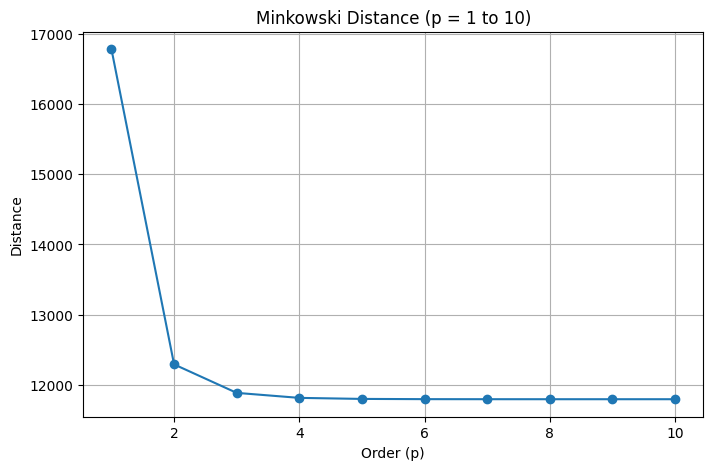

In [ ]:
p_values, my_distances = calculate_minkowski_range(vector1, vector2)

plt.figure(figsize=(8,5))

plt.plot(
    p_values,
    my_distances,
    marker='o'
)

plt.title("Minkowski Distance (p = 1 to 10)")
plt.xlabel("Order (p)")
plt.ylabel("Distance")

plt.grid(True)

plt.show()

In [ ]:
def compare_with_scipy(vector1, vector2):

    comparison = []

    for p in range(1, 11):

        my_distance = minkowski_distance(vector1, vector2, p)

        scipy_distance = minkowski(vector1, vector2, p)

        comparison.append([
            p,
            my_distance,
            scipy_distance
        ])

    return comparison

In [ ]:
comparison = compare_with_scipy(vector1, vector2)

print("========== A4, A5 & A6 ==========\n")

print("{:<5} {:<20} {:<20}".format(
    "p",
    "My Function",
    "SciPy Function"
))

print("-" * 50)

for row in comparison:

    print("{:<5} {:<20.6f} {:<20.6f}".format(
        row[0],
        row[1],
        row[2]
    ))

========== A4, A5 & A6 ==========

p     My Function          SciPy Function      
--------------------------------------------------
1     16782.000000         16782.000000        
2     12290.371272         12290.371272        
3     11884.374554         11884.374554        
4     11813.182057         11813.182057        
5     11798.359466         11798.359466        
6     11795.032150         11795.032150        
7     11794.251319         11794.251319        
8     11794.062465         11794.062465        
9     11794.015771         11794.015771        
10    11794.004032         11794.004032        


In [ ]:
def dot_product(vector1, vector2):

    if len(vector1) != len(vector2):
        raise ValueError("Vectors must have the same length.")

    result = 0

    for i in range(len(vector1)):
        result += vector1[i] * vector2[i]

    return result

In [ ]:
def euclidean_norm(vector):

    total = 0

    for value in vector:
        total += value ** 2

    return total ** 0.5

In [ ]:
print("========== A7 ==========\n")

my_dot = dot_product(vector1, vector2)
numpy_dot = np.dot(vector1, vector2)

print("Dot Product")
print("My Function :", my_dot)
print("NumPy       :", numpy_dot)

print()

my_norm1 = euclidean_norm(vector1)
numpy_norm1 = np.linalg.norm(vector1)

print("Norm of Vector 1")
print("My Function :", my_norm1)
print("NumPy       :", numpy_norm1)

print()

my_norm2 = euclidean_norm(vector2)
numpy_norm2 = np.linalg.norm(vector2)

print("Norm of Vector 2")
print("My Function :", my_norm2)
print("NumPy       :", numpy_norm2)

========== A7 ==========

Dot Product
My Function : 2710194336.0
NumPy       : 2710194336.0

Norm of Vector 1
My Function : 58439.10812974476
NumPy       : 58439.10812974476

Norm of Vector 2
My Function : 46436.11244494957
NumPy       : 46436.11244494957


In [ ]:
def calculate_mean(data):

    total = 0

    for value in data:
        total += value

    return total / len(data)

In [ ]:
def calculate_variance(data):

    mean = calculate_mean(data)

    total = 0

    for value in data:
        total += (value - mean) ** 2

    return total / len(data)

In [ ]:
def calculate_standard_deviation(data):

    variance = calculate_variance(data)

    return variance ** 0.5

In [ ]:
def dataset_statistics(dataframe):

    means = []
    variances = []
    stds = []

    numeric_df = dataframe.select_dtypes(include=np.number)

    for column in numeric_df.columns:

        values = numeric_df[column].tolist()

        means.append(calculate_mean(values))
        variances.append(calculate_variance(values))
        stds.append(calculate_standard_deviation(values))

    return numeric_df.columns, means, variances, stds

In [ ]:
columns, means, variances, stds = dataset_statistics(label_df)

print("========== A8 ==========\n")

for i in range(len(columns)):

    print(f"{columns[i]}")

    print("Mean     :", means[i])
    print("Variance :", variances[i])
    print("Std Dev  :", stds[i])

    print("-" * 40)

========== A8 ==========

ID
Mean     : 5592.159821428571
Variance : 10536109.703921402
Std Dev  : 3245.9374152810465
----------------------------------------
Year_Birth
Mean     : 1968.8058035714287
Variance : 143.5538056042729
Std Dev  : 11.98139414276456
----------------------------------------
Education
Mean     : 0.9821428571428571
Variance : 1.5800382653060991
Std Dev  : 1.2569957300269954
----------------------------------------
Marital_Status
Mean     : 1.496875
Variance : 1.152668805803571
Std Dev  : 1.0736241455013813
----------------------------------------
Income
Mean     : nan
Variance : nan
Std Dev  : nan
----------------------------------------
Kidhome
Mean     : 0.44419642857142855
Variance : 0.28974310427295247
Std Dev  : 0.5382779061720372
----------------------------------------
Teenhome
Mean     : 0.50625
Variance : 0.296389508928571
Std Dev  : 0.5444166684889167
----------------------------------------
Dt_Customer
Mean     : 283.6870535714286
Variance : 33132.02572

In [ ]:
numeric_df = label_df.select_dtypes(include=np.number)

numpy_means = np.mean(numeric_df, axis=0)

numpy_stds = np.std(numeric_df, axis=0)

print("========== A9 ==========\n")

for i, column in enumerate(numeric_df.columns):

    print(column)

    print("My Mean      :", means[i])
    print("NumPy Mean   :", numpy_means[i])

    print("My Std Dev   :", stds[i])
    print("NumPy Std Dev:", numpy_stds[i])

    print("-" * 40)

========== A9 ==========

ID
My Mean      : 5592.159821428571
NumPy Mean   : 5592.159821428571
My Std Dev   : 3245.9374152810465
NumPy Std Dev: 3245.9374152810465
----------------------------------------
Year_Birth
My Mean      : 1968.8058035714287
NumPy Mean   : 1968.8058035714287
My Std Dev   : 11.98139414276456
NumPy Std Dev: 11.981394142764593
----------------------------------------
Education
My Mean      : 0.9821428571428571
NumPy Mean   : 0.9821428571428571
My Std Dev   : 1.2569957300269954
NumPy Std Dev: 1.2569957300269954
----------------------------------------
Marital_Status
My Mean      : 1.496875
NumPy Mean   : 1.496875
My Std Dev   : 1.0736241455013813
NumPy Std Dev: 1.0736241455013813
----------------------------------------
Income
My Mean      : nan
NumPy Mean   : 52247.25135379061
My Std Dev   : nan
NumPy Std Dev: 25167.39617416297
----------------------------------------
Kidhome
My Mean      : 0.44419642857142855
NumPy Mean   : 0.44419642857142855
My Std Dev   : 0.538

/tmp/ipykernel_721/588442039.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("NumPy Mean   :", numpy_means[i])
/tmp/ipykernel_721/588442039.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print("NumPy Std Dev:", numpy_stds[i])


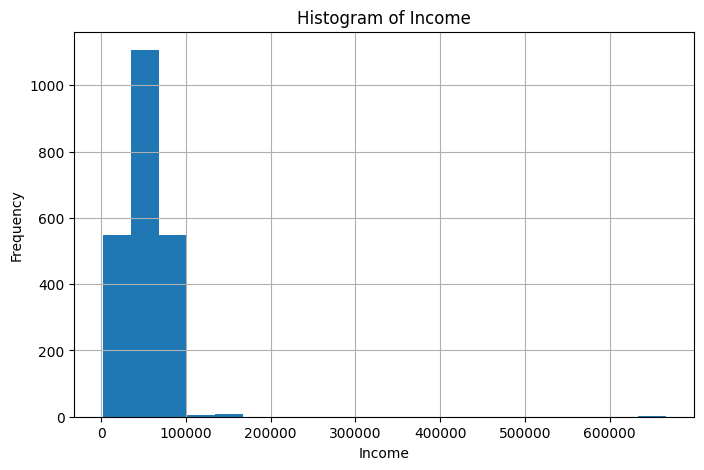


Mean     : 52247.25135379061
Variance : 633397830.1872728


In [ ]:
feature = "Income"

data = label_df[feature].dropna()

plt.figure(figsize=(8,5))

plt.hist(data, bins=20)

plt.title(f"Histogram of {feature}")

plt.xlabel(feature)

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

print()

print("Mean     :", calculate_mean(data.tolist()))

print("Variance :", calculate_variance(data.tolist()))

In [ ]:
def initialize_centroids(data, k):

    centroids = data[:k].copy()

    return centroids

In [ ]:
def assign_clusters(data, centroids):

    clusters = []

    for point in data:

        distances = []

        for centroid in centroids:

            distance = minkowski_distance(point, centroid, 2)

            distances.append(distance)

        cluster = np.argmin(distances)

        clusters.append(cluster)

    return np.array(clusters)

In [ ]:
def update_centroids(data, clusters, k):

    new_centroids = []

    for cluster in range(k):

        cluster_points = data[clusters == cluster]

        if len(cluster_points) == 0:

            new_centroids.append(np.zeros(data.shape[1]))

        else:

            new_centroids.append(np.mean(cluster_points, axis=0))

    return np.array(new_centroids)

In [ ]:
def kmeans(data, k=3, max_iterations=100):

    centroids = initialize_centroids(data, k)

    for iteration in range(max_iterations):

        clusters = assign_clusters(data, centroids)

        new_centroids = update_centroids(data, clusters, k)

        if np.allclose(centroids, new_centroids):

            break

        centroids = new_centroids

    return clusters, centroids

In [ ]:
numeric_df = label_df.select_dtypes(include=np.number)

data = numeric_df.to_numpy()

In [ ]:
clusters, centroids = kmeans(data, k=3)

In [ ]:
print("========== A11 ==========\n")

print("Number of Clusters :", len(np.unique(clusters)))

print("\nCentroids:\n")

print(centroids)

print("\nCluster Distribution:\n")

unique, counts = np.unique(clusters, return_counts=True)

for c, count in zip(unique, counts):

    print(f"Cluster {c} : {count} samples")

========== A11 ==========

Number of Clusters : 1

Centroids:

[[5.59215982e+03 1.96880580e+03 9.82142857e-01 1.49687500e+00
             nan 4.44196429e-01 5.06250000e-01 2.83687054e+02
  4.91093750e+01 3.03935714e+02 2.63022321e+01 1.66950000e+02
  3.75254464e+01 2.70629464e+01 4.40218750e+01 2.32500000e+00
  4.08482143e+00 2.66205357e+00 5.79017857e+00 5.31651786e+00
  7.27678571e-02 7.45535714e-02 7.27678571e-02 6.42857143e-02
  1.33928571e-02 9.37500000e-03 3.00000000e+00 1.10000000e+01
  1.49107143e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0

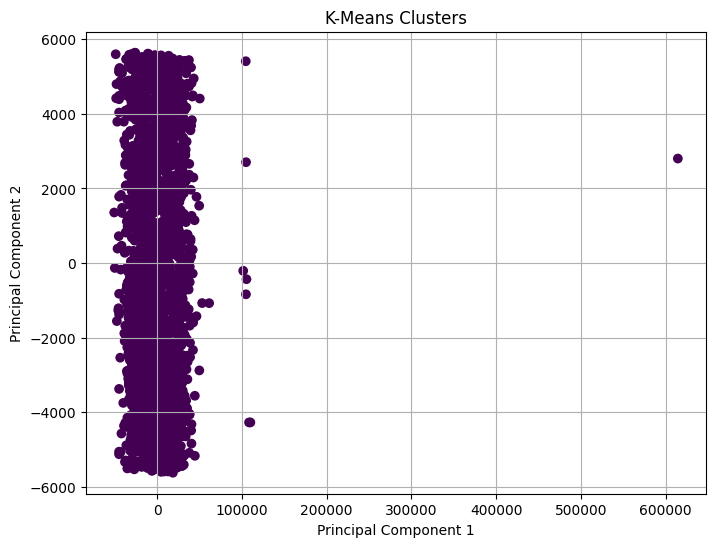

In [ ]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer # Import SimpleImputer

pca = PCA(n_components=2)

# Impute NaN values before PCA
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data)

reduced = pca.fit_transform(data_imputed)

plt.figure(figsize=(8,6))

plt.scatter(
    reduced[:,0],
    reduced[:,1],
    c=clusters
)

plt.title("K-Means Clusters")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.grid(True)

plt.show()

EEG dataset :

Loaded file: h12.edf
Available EEG Channels: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']

--- Statistical Analysis ---
Selected Feature (Channel): Fp1
Mean Amplitude: -9.920364e-09 Volts
Variance: 3.511349e-10

Histogram Bin Edges (Bucket limits):
[-2.58405648e-04 -2.43742050e-04 -2.29078452e-04 -2.14414854e-04
 -1.99751256e-04 -1.85087658e-04 -1.70424060e-04 -1.55760462e-04
 -1.41096863e-04 -1.26433265e-04 -1.11769667e-04 -9.71060694e-05
 -8.24424714e-05 -6.77788734e-05 -5.31152753e-05 -3.84516773e-05
 -2.37880793e-05 -9.12448126e-06  5.53911676e-06  2.02027148e-05
  3.48663128e-05  4.95299108e-05  6.41935089e-05  7.88571069e-05
  9.35207049e-05  1.08184303e-04  1.22847901e-04  1.37511499e-04
  1.52175097e-04  1.66838695e-04  1.81502293e-04]
Histogram Counts (Data points per bucket):
[    5    27    21    24    15    28    31    41   109   265   249   362
   568  1158  3367  9648 31427 93306 71063  9915  1628   8

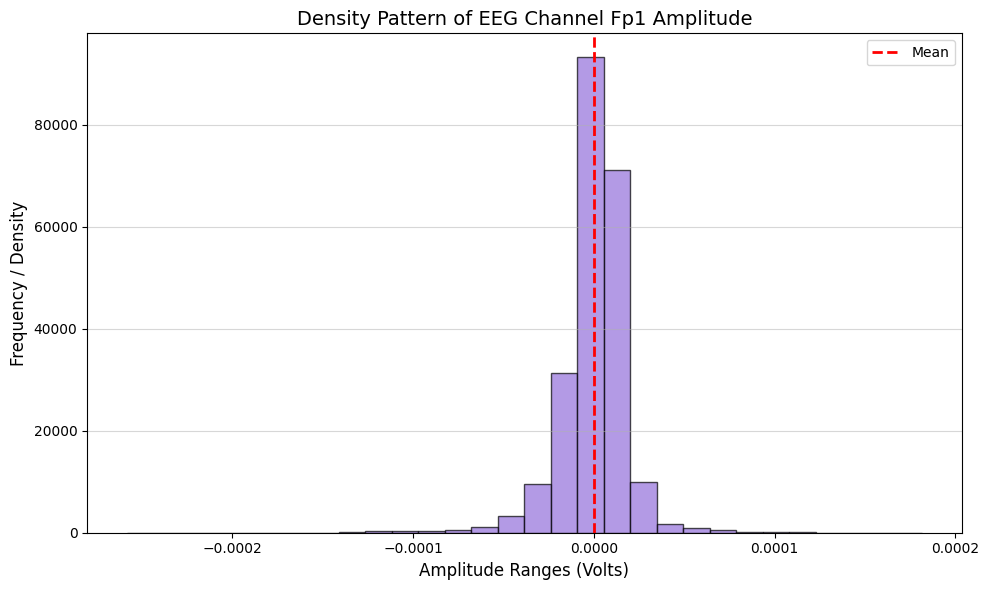

In [ ]:
!pip install mne -q

import zipfile
import os
import numpy as np
import matplotlib.pyplot as plt
import mne

zip_filename = 'dataverse_files.zip'
extract_folder = 'eeg_edf_extracted'

os.makedirs(extract_folder, exist_ok=True)
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

edf_files = []
for root, dirs, files in os.walk(extract_folder):
    for file in files:
        if file.lower().endswith('.edf'):
            edf_files.append(os.path.join(root, file))

if not edf_files:
    raise ValueError("No .edf files were found in the unzipped folder.")

edf_path = edf_files[0]
print(f"Loaded file: {os.path.basename(edf_path)}")

raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
channels = raw.ch_names
print(f"Available EEG Channels: {channels}")

feature_channel = channels[0]

data, times = raw[feature_channel, :]
feature_data = data[0]

mean_val = np.mean(feature_data)
variance_val = np.var(feature_data)

print("\n--- Statistical Analysis ---")
print(f"Selected Feature (Channel): {feature_channel}")
print(f"Mean Amplitude: {mean_val:e} Volts")
print(f"Variance: {variance_val:e}")

counts, bin_edges = np.histogram(feature_data, bins=30)
print("\nHistogram Bin Edges (Bucket limits):")
print(bin_edges)
print("Histogram Counts (Data points per bucket):")
print(counts)

plt.figure(figsize=(10, 6))
plt.hist(feature_data, bins=30, color='mediumpurple', edgecolor='black', alpha=0.7)

plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean')

plt.title(f'Density Pattern of EEG Channel {feature_channel} Amplitude', fontsize=14)
plt.xlabel('Amplitude Ranges (Volts)', fontsize=12)
plt.ylabel('Frequency / Density', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import minkowski
import mne

zip_filename = 'dataverse_files.zip'
extract_folder = 'eeg_edf_extracted'

if not os.path.exists(extract_folder):
    os.makedirs(extract_folder, exist_ok=True)
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall(extract_folder)

edf_files = [os.path.join(root, file)
             for root, dirs, files in os.walk(extract_folder)
             for file in files if file.lower().endswith('.edf')]

if not edf_files:
    raise ValueError("No EDF files found! Check your zip file.")

edf_path = edf_files[0]
raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)

data_matrix = raw.get_data()

print(f"Dataset successfully loaded from: {os.path.basename(edf_path)}")
print(f"Data Matrix Shape: {data_matrix.shape} (Channels x Timepoints)")

Dataset successfully loaded from: h12.edf
Data Matrix Shape: (19, 225000) (Channels x Timepoints)


--- A4 & A5: MINKOWSKI DISTANCE PLOT ---


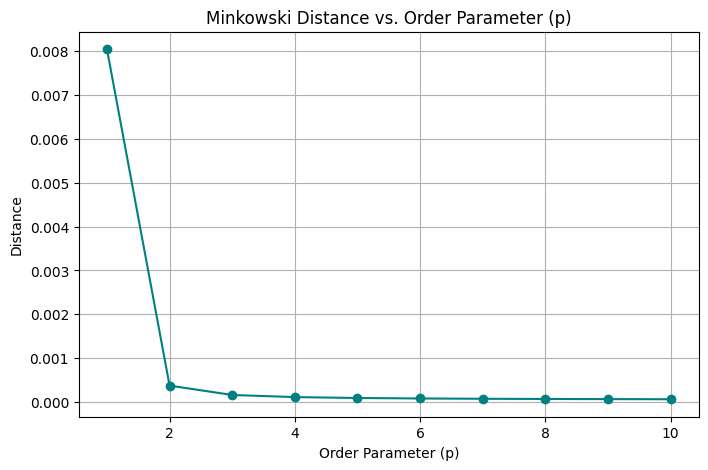


--- A6: DISTANCE FUNCTION COMPARISON ---
Custom Minkowski (p=3): 0.0001633292497164647
SciPy Minkowski (p=3):  0.0001633292497164647
Do they match? True


In [ ]:
def calculate_minkowski_distance(vec_a, vec_b, p):
    diff = np.abs(np.array(vec_a) - np.array(vec_b))
    return np.sum(diff ** p) ** (1 / p)

vector_A = data_matrix[0, :1000]
vector_B = data_matrix[1, :1000]

print("--- A4 & A5: MINKOWSKI DISTANCE PLOT ---")
p_values = list(range(1, 11))
distances = []

for p in p_values:
    dist = calculate_minkowski_distance(vector_A, vector_B, p)
    distances.append(dist)

plt.figure(figsize=(8, 5))
plt.plot(p_values, distances, marker='o', linestyle='-', color='teal')
plt.title('Minkowski Distance vs. Order Parameter (p)')
plt.xlabel('Order Parameter (p)')
plt.ylabel('Distance')
plt.grid(True)
plt.show()

print("\n--- A6: DISTANCE FUNCTION COMPARISON ---")
custom_dist_p3 = calculate_minkowski_distance(vector_A, vector_B, p=3)
scipy_dist_p3 = minkowski(vector_A, vector_B, p=3)

print(f"Custom Minkowski (p=3): {custom_dist_p3}")
print(f"SciPy Minkowski (p=3):  {scipy_dist_p3}")
print(f"Do they match? {np.isclose(custom_dist_p3, scipy_dist_p3)}")

In [ ]:
def calculate_dot_product(vec_a, vec_b):
    return sum(a * b for a, b in zip(vec_a, vec_b))

def calculate_vector_length(vec):
    return sum(v ** 2 for v in vec) ** 0.5

print("--- A7: VECTOR OPERATIONS COMPARISON ---")

custom_dot = calculate_dot_product(vector_A, vector_B)
numpy_dot = np.dot(vector_A, vector_B)

custom_len = calculate_vector_length(vector_A)
numpy_len = np.linalg.norm(vector_A)

print(f"Custom Dot Product: {custom_dot:e}")
print(f"NumPy Dot Product:  {numpy_dot:e}")
print("-" * 30)
print(f"Custom Vector Length: {custom_len:e}")
print(f"NumPy Vector Length:  {numpy_len:e}")

--- A7: VECTOR OPERATIONS COMPARISON ---
Custom Dot Product: 3.594025e-07
NumPy Dot Product:  3.594025e-07
------------------------------
Custom Vector Length: 6.168371e-04
NumPy Vector Length:  6.168371e-04


In [ ]:
def calculate_statistics(data_mat, axis=0):
    data = np.array(data_mat)
    n = data.shape[axis]

    mean_vec = np.sum(data, axis=axis) / n

    if axis == 0:
        diff_sq = (data - mean_vec) ** 2
    else:
        diff_sq = (data - mean_vec[:, np.newaxis]) ** 2

    variance_vec = np.sum(diff_sq, axis=axis) / n
    std_vec = variance_vec ** 0.5

    return mean_vec, variance_vec, std_vec

print("--- A8 & A9: STATISTICS COMPARISON ---")
feature_subset = data_matrix[:5, :1000].T

custom_mean, custom_var, custom_std = calculate_statistics(feature_subset, axis=0)

numpy_mean = np.mean(feature_subset, axis=0)
numpy_std = np.std(feature_subset, axis=0)

print(f"Custom Mean Vector (First 3): {custom_mean[:3]}")
print(f"NumPy Mean Vector (First 3):  {numpy_mean[:3]}")
print("-" * 30)
print(f"Custom Std Vector (First 3):  {custom_std[:3]}")
print(f"NumPy Std Vector (First 3):   {numpy_std[:3]}")

--- A8 & A9: STATISTICS COMPARISON ---
Custom Mean Vector (First 3): [ 1.60680261e-07 -5.89625011e-07  7.62514690e-07]
NumPy Mean Vector (First 3):  [ 1.60680261e-07 -5.89625011e-07  7.62514690e-07]
------------------------------
Custom Std Vector (First 3):  [1.95054390e-05 2.18935036e-05 6.33881039e-06]
NumPy Std Vector (First 3):   [1.95054390e-05 2.18935036e-05 6.33881039e-06]


--- A10: DENSITY PATTERN (HISTOGRAM) ---
Feature Mean: -9.920364e-09 Volts
Feature Variance: 3.511349e-10


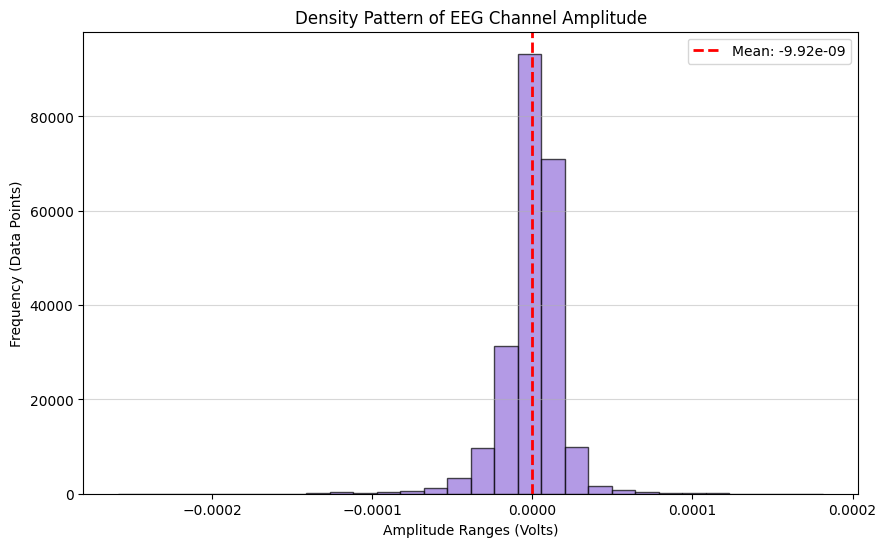

In [ ]:
print("--- A10: DENSITY PATTERN (HISTOGRAM) ---")
feature_data = data_matrix[0, :]

feature_mean = np.mean(feature_data)
feature_variance = np.var(feature_data)

print(f"Feature Mean: {feature_mean:e} Volts")
print(f"Feature Variance: {feature_variance:e}")

counts, bins = np.histogram(feature_data, bins=30)

plt.figure(figsize=(10, 6))
plt.hist(feature_data, bins=30, color='mediumpurple', edgecolor='black', alpha=0.7)
plt.axvline(feature_mean, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {feature_mean:.2e}')
plt.title('Density Pattern of EEG Channel Amplitude')
plt.xlabel('Amplitude Ranges (Volts)')
plt.ylabel('Frequency (Data Points)')
plt.legend()
plt.grid(axis='y', alpha=0.5)
plt.show()

--- A11: K-MEANS CLUSTERING ---
Calculated Cluster Centroids:
[[-2.93339882e-05 -3.22557152e-05]
 [ 4.26176176e-07 -8.83924904e-07]
 [ 2.42449693e-05  2.68346255e-05]]


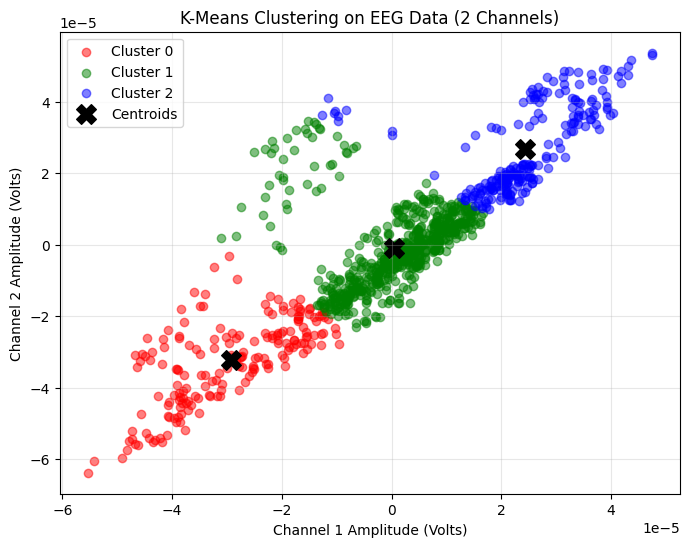

In [ ]:
def k_means_clustering(data, k, max_iters=100):
    data = np.array(data)
    n_samples = data.shape[0]

    np.random.seed(42)
    initial_indices = np.random.choice(n_samples, k, replace=False)
    centroids = data[initial_indices]

    labels = np.zeros(n_samples)

    for _ in range(max_iters):
        distances = np.zeros((n_samples, k))
        for i in range(k):
            diff = data - centroids[i]
            distances[:, i] = np.sum(diff ** 2, axis=1) ** 0.5

        new_labels = np.argmin(distances, axis=1)

        if np.array_equal(labels, new_labels):
            break

        labels = new_labels

        for i in range(k):
            cluster_points = data[labels == i]
            if len(cluster_points) > 0:
                centroids[i] = np.sum(cluster_points, axis=0) / len(cluster_points)

    return centroids, labels

print("--- A11: K-MEANS CLUSTERING ---")
clustering_subset = data_matrix[:2, :1000].T

centroids, labels = k_means_clustering(clustering_subset, k=3, max_iters=100)

print("Calculated Cluster Centroids:")
print(centroids)

plt.figure(figsize=(8, 6))
colors = ['red', 'green', 'blue']

for i in range(3):
    cluster_points = clustering_subset[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], c=colors[i], label=f'Cluster {i}', alpha=0.5)

plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='X', s=200, label='Centroids')
plt.title('K-Means Clustering on EEG Data (2 Channels)')
plt.xlabel('Channel 1 Amplitude (Volts)')
plt.ylabel('Channel 2 Amplitude (Volts)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance
from sklearn.cluster import KMeans

np.random.seed(42)

marketing_f1 = np.random.uniform(20, 60, 500)
marketing_f2 = np.random.normal(50000, 15000, 500)
marketing_data = np.column_stack((marketing_f1, marketing_f2))

eeg_f1 = np.random.normal(0, 5, 500)
eeg_f2 = np.random.normal(0, 2, 500)
eeg_data = np.column_stack((eeg_f1, eeg_f2))

vec_a = marketing_data[0]
vec_b = marketing_data[1]
p_values = list(range(1, 11))
distances = [distance.minkowski(vec_a, vec_b, p) for p in p_values]

plt.figure(figsize=(8, 5))
plt.plot(p_values, distances, marker='o', linestyle='-', color='b')
plt.title("Minkowski Distance vs. p-value")
plt.xlabel("Order Parameter (p)")
plt.ylabel("Distance")
plt.grid(True)
plt.tight_layout()
plt.savefig("minkowski_distance.png")
plt.close()

plt.figure(figsize=(8, 5))
plt.hist(marketing_f2, bins=20, color='orange', edgecolor='black', alpha=0.7)
plt.title("Density Pattern of Marketing Feature")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.savefig("marketing_histogram.png")
plt.close()

plt.figure(figsize=(8, 5))
plt.hist(eeg_f1, bins=30, color='purple', edgecolor='black', alpha=0.7)
plt.title("Density Pattern of EEG Signal Feature")
plt.xlabel("Voltage Amplitude")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.savefig("eeg_histogram.png")
plt.close()

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
marketing_clusters = kmeans.fit_predict(marketing_data)
centroids = kmeans.cluster_centers_

plt.figure(figsize=(8, 5))
plt.scatter(marketing_data[:, 0], marketing_data[:, 1], c=marketing_clusters, cmap='viridis', alpha=0.6)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=150)
plt.title("K-Means Clustering on Dataset (K=3)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.savefig("kmeans_clusters.png")
plt.close()